# Pre-processing Berita CNN

# Mengakses Google Drive di Google Colab
Kode ini digunakan untuk menghubungkan (mount) akun Google Drive ke lingkungan kerja Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Berpindah Direktori ke Folder di Google Drive
berpindah ke folder tertentu di dalam Google Drive melalui command line interface (CLI) di Google Colab.

In [ ]:
cd /content/drive/MyDrive/PPW/berita

/content/drive/MyDrive/PPW/berita


# Instalasi Library Sastrawi di Google Colab
Perintah !pip install Sastrawi digunakan untuk menginstal library Sastrawi, yang berfungsi dalam proses pemrosesan bahasa alami (Natural Language Processing / NLP) khusus untuk Bahasa Indonesia.

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load data
file_path = '/content/drive/MyDrive/PPW/berita/cnn_berita.csv'
df = pd.read_csv(file_path)

# Tampilkan 5 baris pertama
df.head()


,Judul,Kategori,Isi,URL
0,FOTO: Demo Ojol di Depan DPR,Nasional,"Jakarta, CNN Indonesia --\n ...",https://www.cnnindonesia.com/nasional/20250917...
1,"Menko Djamari Lapor Harta Tahun 2002, Kekayaan...",Nasional,"Jakarta, CNN Indonesia -- Jenderal TNI (purn) ...",https://www.cnnindonesia.com/nasional/20250917...
2,Kecelakaan Bus Nakes Bromo: Tewas Jadi 9 Orang...,Nasional,"Jakarta, CNN Indonesia -- Korban meninggal dun...",https://www.cnnindonesia.com/nasional/20250917...
3,"Berebut Bahas RUU Pemilu, Rapat Evaluasi Prole...",Nasional,"Jakarta, CNN Indonesia -- Rapat evaluasi sekal...",https://www.cnnindonesia.com/nasional/20250917...
4,"Daftar Lengkap Menteri, Wamen dan Pejabat Dila...",Nasional,"Jakarta, CNN Indonesia -- Presiden Prabowo Sub...",https://www.cnnindonesia.com/nasional/20250917...


# Import Library & Load Data
Kode ini digunakan untuk memproses data CSV dari file cnn_berita.csv, dengan cara mengambil hanya kolom isi, lalu menghapus baris yang kosong (NaN) (jika ada)

In [ ]:
import pandas as pd

# Load data
file_path = '/content/drive/MyDrive/PPW/berita/cnn_berita.csv'
df = pd.read_csv(file_path)

# Hanya ambil kolom 'isi' dan buang NaN
isi_df = df[['Isi']].dropna().reset_index(drop=True)

# Simpan ke CSV
isi_df.to_csv('/content/drive/MyDrive/PPW/cnn_berita_isi.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
isi_df.head(10)


Data berhasil disimpan ke CSV!



,Isi
0,"Jakarta, CNN Indonesia --\n ..."
1,"Jakarta, CNN Indonesia -- Jenderal TNI (purn) ..."
2,"Jakarta, CNN Indonesia -- Korban meninggal dun..."
3,"Jakarta, CNN Indonesia -- Rapat evaluasi sekal..."
4,"Jakarta, CNN Indonesia -- Presiden Prabowo Sub..."
5,"Jakarta, CNN Indonesia -- Boyamin Saiman, peng..."
6,"Jakarta, CNN Indonesia -- Komisi Pemberantasan..."
7,"Jakarta, CNN Indonesia -- Pengemudi ojek onlin..."
8,"Jakarta, CNN Indonesia -- Wakil Ketua Komisi X..."
9,"Jakarta, CNN Indonesia -- Pengemudi ojek onlin..."


Kode ini digunakan untuk menampilkan jumlah data sebelum dan sesudah penghapusan nilai kosong (NaN) pada kolom abstrak_indo.

In [ ]:
# Jumlah data awal sebelum drop NaN
total_awal = len(df)
print("Jumlah data awal:", total_awal)
total_setelah_drop = len(isi_df)
print("Jumlah data setelah drop NaN:", total_setelah_drop)

Jumlah data awal: 187
Jumlah data setelah drop NaN: 187


# Cleansing (Membersihkan Teks)
Kode tersebut melakukan pembersihan teks pada kolom isi dengan mengubah semua huruf menjadi huruf kecil agar konsisten dan tidak membedakan antara huruf besar dan kecil. Selain itu, kode ini menghapus semua angka, tanda baca, dan simbol sehingga hanya tersisa huruf dan spasi, yang bertujuan menghilangkan karakter yang tidak relevan atau mengganggu proses analisis teks. Terakhir, pembersihan juga menghapus spasi berlebihan, termasuk spasi ganda atau spasi di awal dan akhir kalimat, agar teks menjadi lebih rapi dan mudah diproses. Proses ini penting untuk menyederhanakan dan menormalkan data teks sehingga siap digunakan dalam tahap analisis lebih lanjut seperti tokenisasi, stemming, atau klasifikasi.

In [ ]:
import pandas as pd
import re

# Fungsi cleansing
def cleansing(text):
    text = str(text).lower()                         # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)        # hilangkan angka/simbol
    text = re.sub(r'\s+', ' ', text).strip()        # hilangkan spasi berlebih
    return text

# Terapkan cleansing pada kolom 'isi'
isi_df['cleaned'] = isi_df['Isi'].apply(cleansing)

# Simpan ke CSV
isi_df.to_csv('/content/drive/MyDrive/PPW/berita/cnn_berita_isi_cleaned.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
isi_df[['Isi','cleaned']].head()


Data berhasil disimpan ke CSV!



,Isi,cleaned
0,"Jakarta, CNN Indonesia --\n ...",jakarta cnn indonesia sejumlah pengemudi ojek ...
1,"Jakarta, CNN Indonesia -- Jenderal TNI (purn) ...",jakarta cnn indonesia jenderal tni purn djamar...
2,"Jakarta, CNN Indonesia -- Korban meninggal dun...",jakarta cnn indonesia korban meninggal dunia k...
3,"Jakarta, CNN Indonesia -- Rapat evaluasi sekal...",jakarta cnn indonesia rapat evaluasi sekaligus...
4,"Jakarta, CNN Indonesia -- Presiden Prabowo Sub...",jakarta cnn indonesia presiden prabowo subiant...


In [ ]:
!pip install pyspellchecker


# Stopword Removal
Kode ini digunakan untuk menghapus kata-kata umum (stopwords) dalam bahasa Indonesia dari teks yang sudah dibersihkan di kolom cleaned. Dengan menggunakan library Sastrawi, dibuat objek stopword remover yang akan menghilangkan kata-kata seperti “dan”, “di”, “yang”, dan kata umum lain yang biasanya tidak membawa makna penting dalam analisis teks.

Setelah proses penghilangan stopwords selesai, hasilnya disimpan dalam kolom baru bernama no_stopwords. Kemudian, data yang sudah diproses ini disimpan kembali ke file CSV baru cnn_berita_isi_no_stopwords.csv. Langkah ini penting agar teks menjadi lebih fokus pada kata-kata bermakna dan memudahkan analisis selanjutnya seperti klasifikasi atau clustering.

In [ ]:
import pandas as pd
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Buat stopword remover
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()

# Terapkan stopword removal pada kolom 'cleaned' di isi_df
isi_df['no_stopwords'] = isi_df['cleaned'].apply(stopword.remove)

# Simpan hasil ke CSV
isi_df.to_csv('/content/drive/MyDrive/PPW/berita/cnn_berita_isi_no_stopwords.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
isi_df[['cleaned','no_stopwords']].head()


Data berhasil disimpan ke CSV!



,cleaned,no_stopwords
0,jakarta cnn indonesia sejumlah pengemudi ojek ...,jakarta cnn indonesia sejumlah pengemudi ojek ...
1,jakarta cnn indonesia jenderal tni purn djamar...,jakarta cnn indonesia jenderal tni purn djamar...
2,jakarta cnn indonesia korban meninggal dunia k...,jakarta cnn indonesia korban meninggal dunia k...
3,jakarta cnn indonesia rapat evaluasi sekaligus...,jakarta cnn indonesia rapat evaluasi sekaligus...
4,jakarta cnn indonesia presiden prabowo subiant...,jakarta cnn indonesia presiden prabowo subiant...


# Stemming
Kode ini melakukan proses stemming pada teks di kolom no_stopwords menggunakan library Sastrawi, yaitu mengubah kata-kata yang memiliki imbuhan atau variasi menjadi bentuk dasar atau kata dasarnya. Hasil stemming ini disimpan dalam kolom baru stemmed dan kemudian disimpan ke file CSV baru untuk digunakan dalam analisis selanjutnya. Proses stemming penting untuk menyederhanakan variasi kata sehingga model atau analisis teks dapat mengenali kata-kata dengan makna yang sama secara konsisten.

In [ ]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stemmer = StemmerFactory().create_stemmer()

# Terapkan stemming pada kolom 'no_stopwords' di isi_df
isi_df['stemmed'] = isi_df['no_stopwords'].apply(stemmer.stem)

# Simpan hasil ke CSV
isi_df.to_csv('/content/drive/MyDrive/PPW/berita/cnn_berita_isi_stemmed.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
isi_df[['no_stopwords','stemmed']].head()


Data berhasil disimpan ke CSV!



,no_stopwords,stemmed
0,jakarta cnn indonesia sejumlah pengemudi ojek ...,jakarta cnn indonesia jumlah kemudi ojek onlin...
1,jakarta cnn indonesia jenderal tni purn djamar...,jakarta cnn indonesia jenderal tni purn djamar...
2,jakarta cnn indonesia korban meninggal dunia k...,jakarta cnn indonesia korban tinggal dunia cel...
3,jakarta cnn indonesia rapat evaluasi sekaligus...,jakarta cnn indonesia rapat evaluasi sekaligus...
4,jakarta cnn indonesia presiden prabowo subiant...,jakarta cnn indonesia presiden prabowo subiant...


# Tokenisasi
Kode ini melakukan tokenisasi pada teks yang sudah melalui proses stemming di kolom stemmed. Tokenisasi adalah proses memecah kalimat atau teks menjadi potongan-potongan kata (token) yang lebih kecil, biasanya berdasarkan spasi. Fungsi tokenize yang sederhana di sini memecah setiap kalimat menjadi daftar kata-kata dengan menggunakan metode split(). Hasil tokenisasi disimpan dalam kolom baru tokens, yang berisi daftar kata untuk tiap baris teks. Setelah itu, data lengkap dengan token disimpan ke file CSV baru cnn_berita_isi_tokens.csv

In [ ]:
import pandas as pd

# Fungsi tokenisasi sederhana
def tokenize(text):
    return text.split()

# Terapkan tokenisasi pada kolom 'stemmed' di isi_df
isi_df['tokens'] = isi_df['stemmed'].apply(tokenize)

# Simpan hasil ke CSV
isi_df.to_csv('/content/drive/MyDrive/PPW/berita/cnn_berita_isi_tokens.csv', index=False)
print("Data berhasil disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama
isi_df[['stemmed','tokens']].head()


Data berhasil disimpan ke CSV!



,stemmed,tokens
0,jakarta cnn indonesia jumlah kemudi ojek onlin...,"[jakarta, cnn, indonesia, jumlah, kemudi, ojek..."
1,jakarta cnn indonesia jenderal tni purn djamar...,"[jakarta, cnn, indonesia, jenderal, tni, purn,..."
2,jakarta cnn indonesia korban tinggal dunia cel...,"[jakarta, cnn, indonesia, korban, tinggal, dun..."
3,jakarta cnn indonesia rapat evaluasi sekaligus...,"[jakarta, cnn, indonesia, rapat, evaluasi, sek..."
4,jakarta cnn indonesia presiden prabowo subiant...,"[jakarta, cnn, indonesia, presiden, prabowo, s..."


# Hitung Frekuensi Kata
Kode ini digunakan untuk menghitung dan memvisualisasikan frekuensi kemunculan kata dari hasil tokenisasi teks. Pertama, semua token (kata) dari kolom tokens digabung menjadi satu list besar, lalu dihitung frekuensi kemunculan tiap kata menggunakan Counter. Hasil hitungan frekuensi disusun menjadi sebuah DataFrame yang terurut dari kata dengan frekuensi tertinggi hingga terendah, dan diberi nomor ranking mulai dari 1. Data frekuensi kata ini disimpan ke file CSV bernama frekuensi_kata.csv. Selanjutnya, kode ini menampilkan 30 kata yang paling sering muncul beserta jumlah kemunculannya, dan memvisualisasikan data tersebut dalam bentuk grafik batang agar lebih mudah dianalisis secara visual.

Frekuensi kata berhasil disimpan ke CSV!

               kata  frekuensi
rank                          
1         indonesia        431
2             sebut        411
3              jadi        392
4               cnn        349
5             lihat        304
6           jakarta        295
7              kata        289
8           menteri        258
9              laku        216
10            lebih        213
11            tahun        201
12             with        192
13               to        191
14          content        191
15           negara        191
16    advertisement        189
17           scroll        189
18         continue        189
19            video        185
20           israel        184
21           hingga        182
22             lalu        174
23           gambas        174
24            orang        166
25             satu        152
26               rp        148
27             baru        142
28              itu        131
29             buat        1

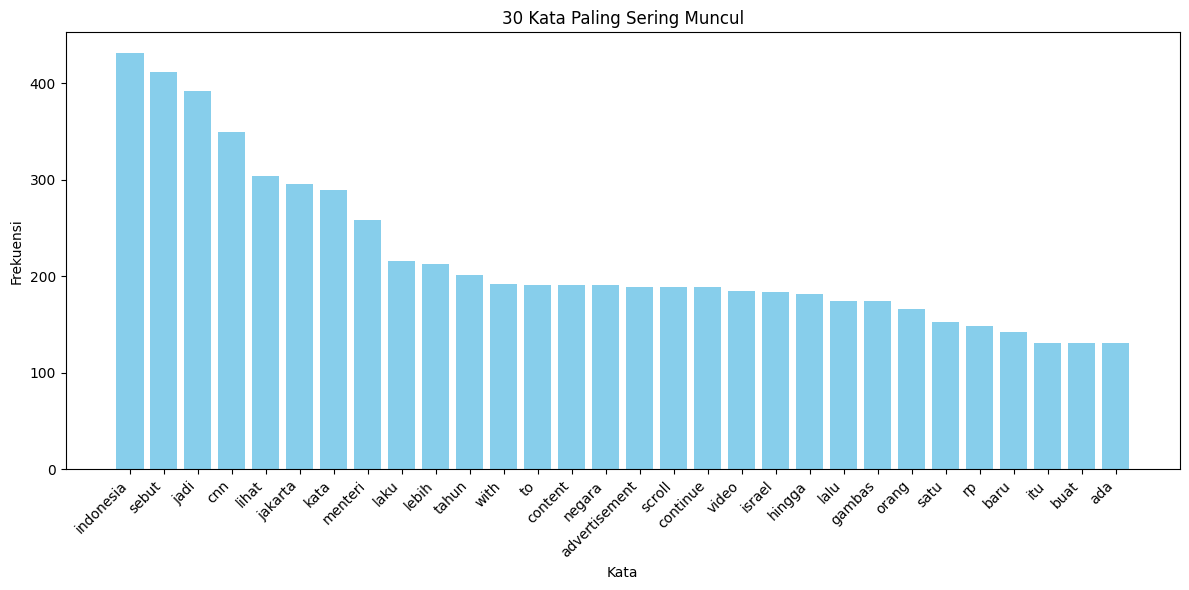

In [ ]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Gabungkan semua token dari isi_df
all_tokens = [tok for tokens in isi_df['tokens'] for tok in tokens]

# Hitung frekuensi kata
word_freq = Counter(all_tokens)

# Jadi DataFrame terurut dari besar ke kecil
freq_df = pd.DataFrame(word_freq.most_common(), columns=['kata','frekuensi'])

# Tambahkan index ranking mulai dari 1
freq_df.index = range(1, len(freq_df)+1)
freq_df.index.name = 'rank'

# Simpan frekuensi kata ke CSV
freq_df.to_csv('/content/drive/MyDrive/PPW/berita/frekuensi_kata.csv', index=True)
print("Frekuensi kata berhasil disimpan ke CSV!\n")

# Tampilkan 30 kata teratas
top_n = 30
print(freq_df.head(top_n))

# Visualisasi 30 kata teratas
top_words = freq_df.head(top_n)
plt.figure(figsize=(12,6))
plt.bar(top_words['kata'], top_words['frekuensi'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title(f"{top_n} Kata Paling Sering Muncul")
plt.tight_layout()
plt.show()
